# `02-llm.ipynb`
- 기존 기계적인 워크플로우 -> LLM 을 삽입

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# State 정의
from typing import TypedDict, Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str  # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'aggressive']]  # 감정 분석
    core_msg:  NotRequired[str]    # 핵심 메세지
    response:  NotRequired[str]    # 최종 답변

In [18]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini') 

# LLM 초기화 + 감정분석 Node
def analyze_sentiment(state: TeacherState):
    prompt = f'''
    아래 문장의 감정을 분류.
    아래 3가지 중 1가지 단어로만 판단.
    positive
    negative
    aggressive

    문장: {state['user_input']}
    '''
    result = llm.invoke(prompt)

    return {'sentiment': result.content}  # 바뀐 부분만 return.

In [4]:
# 나머지 노드
import random

def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}


def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}


def aggressive_node(state: TeacherState):
    return {'core_msg':  '공격적인 표현은 삼가라'}

In [ ]:
# 완성 Node
def make_final_msg(state: TeacherState):
    prompt = f'''
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드를 참조해야해.

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)
    return {'response': result.content}

In [6]:
def router(state: TeacherState):
    return state['sentiment']  # 단순히 다음 노드를 결정할 문자열만 return

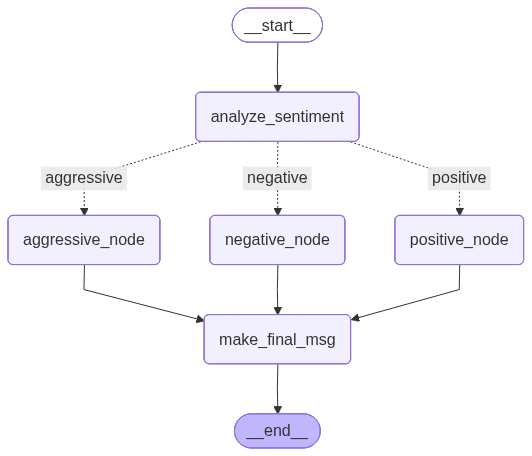

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)
# 노드 등록 (등록 이름과 함수 이름을 맞추기)
graph.add_node('analyze_sentiment', analyze_sentiment)
graph.add_node('positive_node', positive_node)
graph.add_node('negative_node', negative_node)
graph.add_node('aggressive_node', aggressive_node)
graph.add_node('make_final_msg', make_final_msg)

# 엣지 등록
graph.add_edge(START, 'analyze_sentiment')
graph.add_conditional_edges(
    'analyze_sentiment',
    router,
    {   # router 결과값 -> 다음 노드 이름
        'positive': 'positive_node',
        'negative': 'negative_node',
        'aggressive': 'aggressive_node',
    }
)
graph.add_edge('positive_node', 'make_final_msg')
graph.add_edge('negative_node', 'make_final_msg')
graph.add_edge('aggressive_node', 'make_final_msg')
graph.add_edge('make_final_msg', END)

app = graph.compile()

app

In [21]:
app.invoke({'user_input': '바보'})

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '공격적인 표현은 삼가라',
 'response': '상대방에게 상처가 될 수 있으니 공격적인 표현은 삼가 주시기 바랍니다. 서로 존중하는 대화를 나누면 좋겠습니다.'}